In [1]:
import pandas as pd

# Creating dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Mild', 'Cool'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No']
}

df = pd.DataFrame(data)
print(df)

    Outlook Temperature Humidity    Wind PlayTennis
0     Sunny         Hot     High    Weak         No
1     Sunny         Hot     High  Strong         No
2  Overcast         Hot     High    Weak        Yes
3      Rain        Mild     High    Weak        Yes
4      Rain        Cool   Normal    Weak        Yes
5      Rain        Cool   Normal  Strong         No
6  Overcast        Mild   Normal  Strong        Yes
7     Sunny        Cool     High    Weak         No


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_encoded = df.apply(le.fit_transform)
print(df_encoded)

   Outlook  Temperature  Humidity  Wind  PlayTennis
0        2            1         0     1           0
1        2            1         0     0           0
2        0            1         0     1           1
3        1            2         0     1           1
4        1            0         1     1           1
5        1            0         1     0           0
6        0            2         1     0           1
7        2            0         0     1           0


In [3]:
from sklearn.tree import DecisionTreeClassifier

# Features and target
X = df_encoded.drop('PlayTennis', axis=1)
y = df_encoded['PlayTennis']

# Create model using entropy (ID3 concept)
model = DecisionTreeClassifier(criterion='entropy')

# Train model
model.fit(X, y)

DecisionTreeClassifier(criterion='entropy')

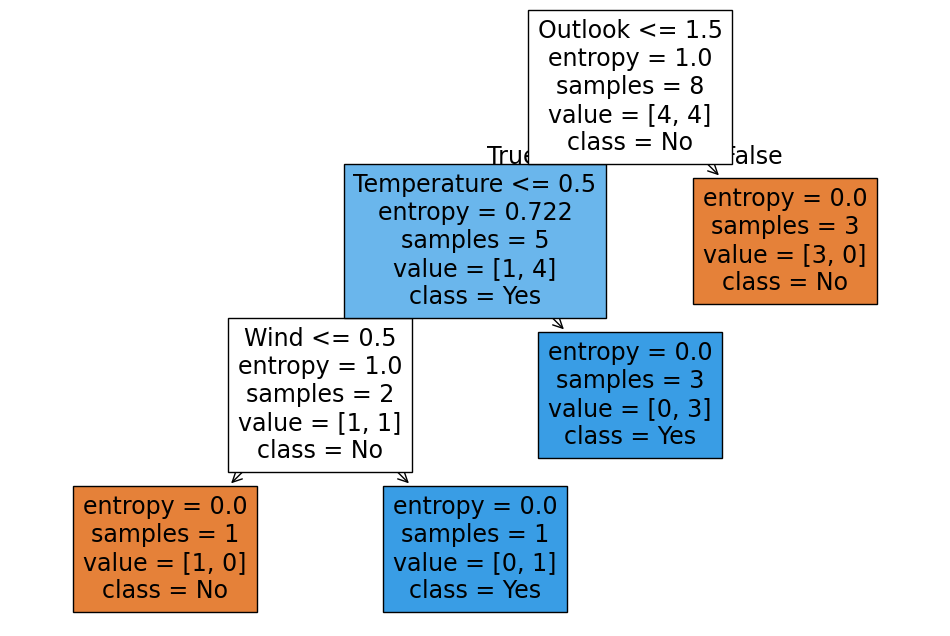

In [4]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
tree.plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

In [5]:
# New sample (encoded manually based on dataset)
new_sample = [[
    le.fit(df['Outlook']).transform(['Sunny'])[0],
    le.fit(df['Temperature']).transform(['Cool'])[0],
    le.fit(df['Humidity']).transform(['High'])[0],
    le.fit(df['Wind']).transform(['Strong'])[0]
]]

prediction = model.predict(new_sample)

if prediction[0] == 1:
    print("Prediction: Play Tennis = Yes")
else:
    print("Prediction: Play Tennis = No")

Prediction: Play Tennis = No


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
